In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from tqdm import tqdm  # Reverted to standard tqdm to fix the Jupyter widget error
import numpy as np
import random
from warmup_scheduler import GradualWarmupScheduler

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# ===============================
# Model Definition
# ===============================
class CustomEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = create_model(
            "efficientnet_b2",
            pretrained=True,
            num_classes=0,
            global_pool=''
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

# ===============================
# Main Execution Block
# ===============================
if __name__ == '__main__':
    # ===============================
    # Paths & Setup
    # ===============================
    train_dir = r"E:\Coins\New_Dataset_V2\train"
    val_dir   = r"E:\Coins\New_Dataset_V2\valid"
    save_dir  = r"E:\Coins\Coin Classification.v8i.yolov8"
    resume_path = r"E:\Coins\Coin Classification.v8i.yolov8\best_model_old.pth"

    os.makedirs(save_dir, exist_ok=True)
    set_seed()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    if device.type == "cuda":
        print(f"GPU Name: {torch.cuda.get_device_name(0)}")

    # ===============================
    # Dataset & Transforms
    # ===============================
    train_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)

    num_classes = len(train_dataset.classes)
    print("Detected classes:", train_dataset.classes)
    print("Total classes:", num_classes)

    # ===============================
    # DataLoaders (Fixed for Jupyter)
    # ===============================
    train_loader = DataLoader(
        train_dataset, batch_size=64, shuffle=True,
        num_workers=0, pin_memory=True  # 0 prevents Jupyter/Windows deadlock
    )
    val_loader = DataLoader(
        val_dataset, batch_size=64, shuffle=False,
        num_workers=0, pin_memory=True  # 0 prevents Jupyter/Windows deadlock
    )

    # ===============================
    # Initialize Model & Load Weights
    # ===============================
    model = CustomEfficientNet(num_classes).to(device)

    if os.path.exists(resume_path):
        print("Loading previous weights...")
        
        # Added weights_only=True to silence the PyTorch security warning
        old_state = torch.load(resume_path, map_location=device, weights_only=True)
        model_state = model.state_dict()
        
        # Filter out weights that don't match the new 19-class architecture
        filtered_state = {
            k: v for k, v in old_state.items()
            if k in model_state and v.size() == model_state[k].size()
        }
        model_state.update(filtered_state)
        model.load_state_dict(model_state)
        print("Backbone weights loaded successfully.")
    else:
        print("Previous model not found. Training from scratch.")

    # ===============================
    # Training Setup
    # ===============================
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    num_epochs = 150
    patience = 15

    cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scheduler = GradualWarmupScheduler(optimizer, multiplier=1, total_epoch=5, after_scheduler=cosine_scheduler)

    # ===============================
    # Training Loop
    # ===============================
    best_acc = 0
    epochs_no_improve = 0

    print("\nStarting Training...")
    for epoch in range(num_epochs):
        
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0.0
        correct, total = 0, 0

        # leave=False keeps the notebook output clean by removing the bar after completion
        train_loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

        for x, y in train_loop:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            
            outputs = model(x)
            loss = criterion(outputs, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Metrics calculation
            train_loss += loss.item() * x.size(0)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
            
            # Live feedback per batch
            current_acc = 100. * correct / total
            train_loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_acc:.2f}%")

        scheduler.step()
        
        epoch_train_loss = train_loss / total
        epoch_train_acc = 100. * correct / total

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        
        val_loop = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Valid", leave=False)

        with torch.no_grad():
            for x, y in val_loop:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                outputs = model(x)
                loss = criterion(outputs, y)

                val_loss += loss.item() * x.size(0)
                _, predicted = outputs.max(1)
                total += y.size(0)
                correct += predicted.eq(y).sum().item()
                
                # Live feedback per batch for validation
                current_val_acc = 100. * correct / total
                val_loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_val_acc:.2f}%")

        epoch_val_loss = val_loss / total
        epoch_val_acc = 100. * correct / total

        # Clear, permanent summary printed at the end of each epoch
        print(f"Epoch {epoch+1:03d}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

        # ===============================
        # Save Best Model & Early Stopping
        # ===============================
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            torch.save(model.state_dict(), os.path.join(save_dir, "best_model_19classes.pth"))
            epochs_no_improve = 0
            print(f" --> Best model saved! (Acc: {best_acc:.2f}%)")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs.")
                break

    # ===============================
    # Save Last Model
    # ===============================
    torch.save(model.state_dict(), os.path.join(save_dir, "last_model_19classes.pth"))
    print("\nTraining completely finished.")

C:\Users\silva\anaconda3\envs\coin_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU Name: NVIDIA GeForce GTX 1660 SUPER
Detected classes: ['Chinese One Yuan Coin', 'Japanese Fifty Yen Coin', 'Japanese Five Hundred Yen Coin', 'Japanese Five Yen Coin', 'Japanese One Hundred Yen Coin', 'Japanese One Yen Coin', 'Japanese Ten Yen Coin', 'Korean Fifty Won Coin', 'Korean Five Hundred Won Coin', 'Korean Five Won Coin', 'Korean One Hundred Won Coin', 'Korean One Won Coin', 'Korean Ten Won Coin', 'Philippine Five Peso Coin', 'Philippine One Peso Coin', 'Philippine Ten Peso Coin', 'Thailand Five Baht Coin', 'Thailand One Baht Coin', 'Thailand Ten Baht Coin']
Total classes: 19
Loading previous weights...
Backbone weights loaded successfully.

Starting Training...


Epoch [1/150] Train:  41%|████▏     | 250/603 [28:18<40:04,  6.81s/it, acc=45.06%, loss=2.4746]  

C:\Users\silva\anaconda3\envs\coin_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce GTX 1660 SUPER
Detected classes: ['Chinese One Yuan Coin', 'Japanese Fifty Yen Coin', 'Japanese Five Hundred Yen Coin', 'Japanese Five Yen Coin', 'Japanese One Hundred Yen Coin', 'Japanese One Yen Coin', 'Japanese Ten Yen Coin', 'Korean Fifty Won Coin', 'Korean Five Hundred Won Coin', 'Korean Five Won Coin', 'Korean One Hundred Won Coin', 'Korean One Won Coin', 'Korean Ten Won Coin', 'Philippine Five Peso Coin', 'Philippine One Peso Coin', 'Philippine Ten Peso Coin', 'Thailand Five Baht Coin', 'Thailand One Baht Coin', 'Thailand Ten Baht Coin']
Total classes: 19
Loading trained model...

Starting Testing...


Testing: 100%|██████████| 76/76 [00:53<00:00,  1.43it/s]



Overall Test Accuracy: 96.32%

Classification Report:
                                precision    recall  f1-score   support

         Chinese One Yuan Coin     0.9247    0.9910    0.9567       223
       Japanese Fifty Yen Coin     0.9831    0.9873    0.9852       236
Japanese Five Hundred Yen Coin     0.8669    0.9729    0.9168       221
        Japanese Five Yen Coin     0.9881    0.9881    0.9881       253
 Japanese One Hundred Yen Coin     0.9880    0.9960    0.9920       249
         Japanese One Yen Coin     0.9302    0.9717    0.9505       247
         Japanese Ten Yen Coin     0.9803    0.9836    0.9819       304
         Korean Fifty Won Coin     0.9465    0.9914    0.9684       232
  Korean Five Hundred Won Coin     0.9563    0.9522    0.9542       230
          Korean Five Won Coin     0.9757    0.9972    0.9863       362
   Korean One Hundred Won Coin     0.9559    0.8857    0.9195       245
           Korean One Won Coin     0.9935    0.9871    0.9903       310
        

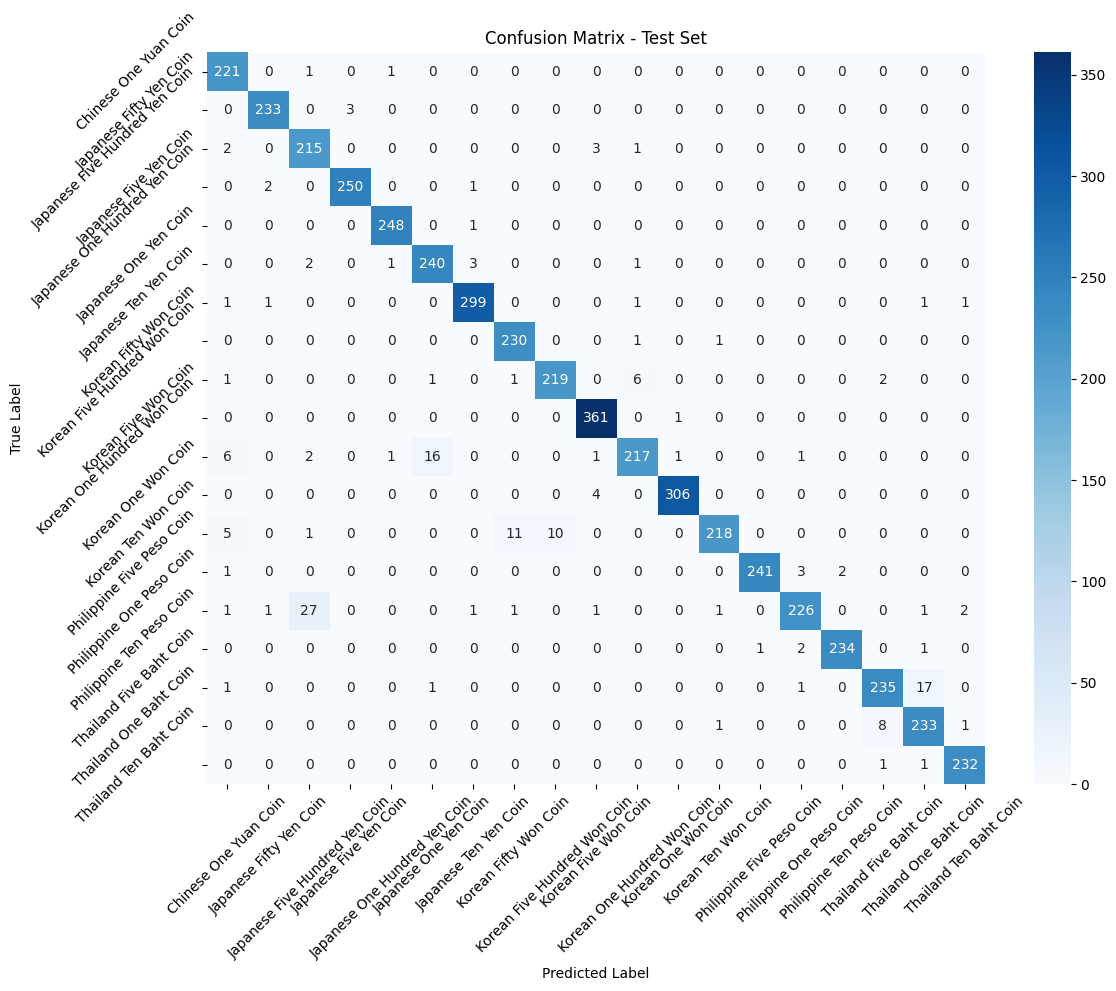


Testing Completed.


In [3]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from tqdm import tqdm
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import seaborn as sns
import matplotlib.pyplot as plt


# ===============================
# Paths
# ===============================
test_dir = r"E:\Coins\New_Dataset_V2\test"
model_path = r"E:\Coins\Coin Classification.v8i.yolov8\best_model_19classes.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


# ===============================
# Model Definition (same as training)
# ===============================
class CustomEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = create_model(
            "efficientnet_b2",
            pretrained=False,
            num_classes=0,
            global_pool=''
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)


# ===============================
# Test Transform (NO augmentation)
# ===============================
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

num_classes = len(test_dataset.classes)
print("Detected classes:", test_dataset.classes)
print("Total classes:", num_classes)


# ===============================
# Load Model
# ===============================
model = CustomEfficientNet(num_classes).to(device)

if not os.path.exists(model_path):
    raise FileNotFoundError("Model file not found!")

print("Loading trained model...")
state_dict = torch.load(model_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()


# ===============================
# Evaluation
# ===============================
print("\nStarting Testing...")

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ===============================
# Overall Accuracy
# ===============================
overall_acc = accuracy_score(all_labels, all_preds)
print(f"\nOverall Test Accuracy: {overall_acc * 100:.2f}%")

# ===============================
# Per-Class Metrics
# ===============================
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=test_dataset.classes,
        digits=4
    )
)

# ===============================
# Confusion Matrix
# ===============================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTesting Completed.")

In [7]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from timm import create_model


# ===============================
# USER INPUT
# ===============================
image_path = r"E:\Coins\New_Dataset_V2\test\Korean Five Won Coin\aug_19.jpg"
model_path = r"E:\Coins\Coin Classification.v8i.yolov8\best_model_19classes.pth"


# ===============================
# Device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ===============================
# Model Definition (same as training)
# ===============================
class CustomEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = create_model(
            "efficientnet_b2",
            pretrained=False,
            num_classes=0,
            global_pool=''
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)


# ===============================
# Load Dataset Classes
# ===============================
# IMPORTANT: Must match training class order
train_dir = r"E:\Coins\New_Dataset_V2\train"

from torchvision import datasets
dummy_dataset = datasets.ImageFolder(train_dir)
class_names = dummy_dataset.classes
num_classes = len(class_names)

print("Loaded Classes:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")


# ===============================
# Load Model
# ===============================
model = CustomEfficientNet(num_classes).to(device)

if not os.path.exists(model_path):
    raise FileNotFoundError("Model file not found!")

print("Loading trained model...")
state_dict = torch.load(model_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()


# ===============================
# Image Transform (NO augmentation)
# ===============================
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


# ===============================
# Predict Function
# ===============================
def predict_image(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError("Image file not found!")

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence = confidence.item() * 100

    print("\n==============================")
    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")
    print("==============================\n")


# ===============================
# Run Prediction
# ===============================
predict_image(image_path)

Using device: cuda
Loaded Classes:
0: Chinese One Yuan Coin
1: Japanese Fifty Yen Coin
2: Japanese Five Hundred Yen Coin
3: Japanese Five Yen Coin
4: Japanese One Hundred Yen Coin
5: Japanese One Yen Coin
6: Japanese Ten Yen Coin
7: Korean Fifty Won Coin
8: Korean Five Hundred Won Coin
9: Korean Five Won Coin
10: Korean One Hundred Won Coin
11: Korean One Won Coin
12: Korean Ten Won Coin
13: Philippine Five Peso Coin
14: Philippine One Peso Coin
15: Philippine Ten Peso Coin
16: Thailand Five Baht Coin
17: Thailand One Baht Coin
18: Thailand Ten Baht Coin
Loading trained model...

Prediction: Korean Five Won Coin
Confidence: 89.32%

